# MMVR: Millimeter-wave Multi-View Radar Dataset and Benchmark for Indoor Perception

In [5]:
import numpy as np

In [6]:
# root = sessionID+'/alignment/'
index = 'test_example/00383'

In [7]:
# for plot
import matplotlib.pyplot as plt
import matplotlib.patches as patches
# joints connections for 2d keypoints
connections = np.array([[13, 15], [11, 13], [14, 16], [12, 14], [11, 12],
                [5, 11], [6, 12], [5, 6], [5, 7], [6, 8], [7, 9],
                [8, 10], [1, 2], [0, 1], [0, 2], [1, 3], [2, 4],
                [3, 5], [4, 6]])

## Load npz files for Heatmaps and Annotations

In [13]:
# Meta info
data = np.load(index + '_meta.npz')
global_id = data['global_frame_id']
# Horizontal/Vertical heatmaps
data = np.load(index + '_radar.npz')
hori = data['hm_hori']  # (256, 128)
vert = data['hm_vert']  # (256, 128)
print(hori)
# 2D Bounding Boxes
data = np.load(index + '_bbox.npz')
bbox_i= data['bbox_i']  # (n, 5)
bbox_hori = data['bbox_hori']  # (n, 4)
bbox_vert = data['bbox_vert']  # (n, 4)
# 2D keypoints
data = np.load(index + '_pose.npz')
kp = data['kp']  # (n, 17, 3)
print(kp)
# 2D Segmentation masks
data = np.load(index + '_mask.npz')
mask = data['mask']  # (n, 480, 640)

[[5.8494276e+07 8.1760576e+07 8.6663392e+07 ... 2.0342972e+07
  1.9994600e+07 1.9443976e+07]
 [4.9285828e+07 7.1285952e+07 7.9780552e+07 ... 2.0980208e+07
  2.0649432e+07 2.0248896e+07]
 [4.0896632e+07 5.9900616e+07 7.0187328e+07 ... 2.2080468e+07
  2.1927372e+07 2.1980174e+07]
 ...
 [1.0919021e+07 1.0873761e+07 1.0459195e+07 ... 1.6084270e+07
  1.3811232e+07 1.4943961e+07]
 [1.1279504e+07 1.1273297e+07 1.1012816e+07 ... 1.6280638e+07
  1.4249508e+07 1.4998171e+07]
 [1.1527122e+07 1.1431614e+07 1.1161299e+07 ... 1.6510790e+07
  1.4552357e+07 1.5154381e+07]]
[[[3.9710938e+02 1.6289062e+02 2.5480688e-03]
  [3.9710938e+02 1.6289062e+02 3.5981692e-03]
  [4.2289062e+02 1.6242188e+02 3.5024646e-03]
  [3.9710938e+02 1.6242188e+02 8.9631832e-01]
  [4.2289062e+02 1.6242188e+02 8.7467968e-01]
  [3.8585938e+02 1.8585938e+02 8.4605265e-01]
  [4.4164062e+02 1.8914062e+02 8.5772043e-01]
  [3.7460938e+02 2.2757812e+02 8.2906687e-01]
  [4.5289062e+02 2.3367188e+02 8.2530844e-01]
  [3.7085938e+02 2.641

## Visualization

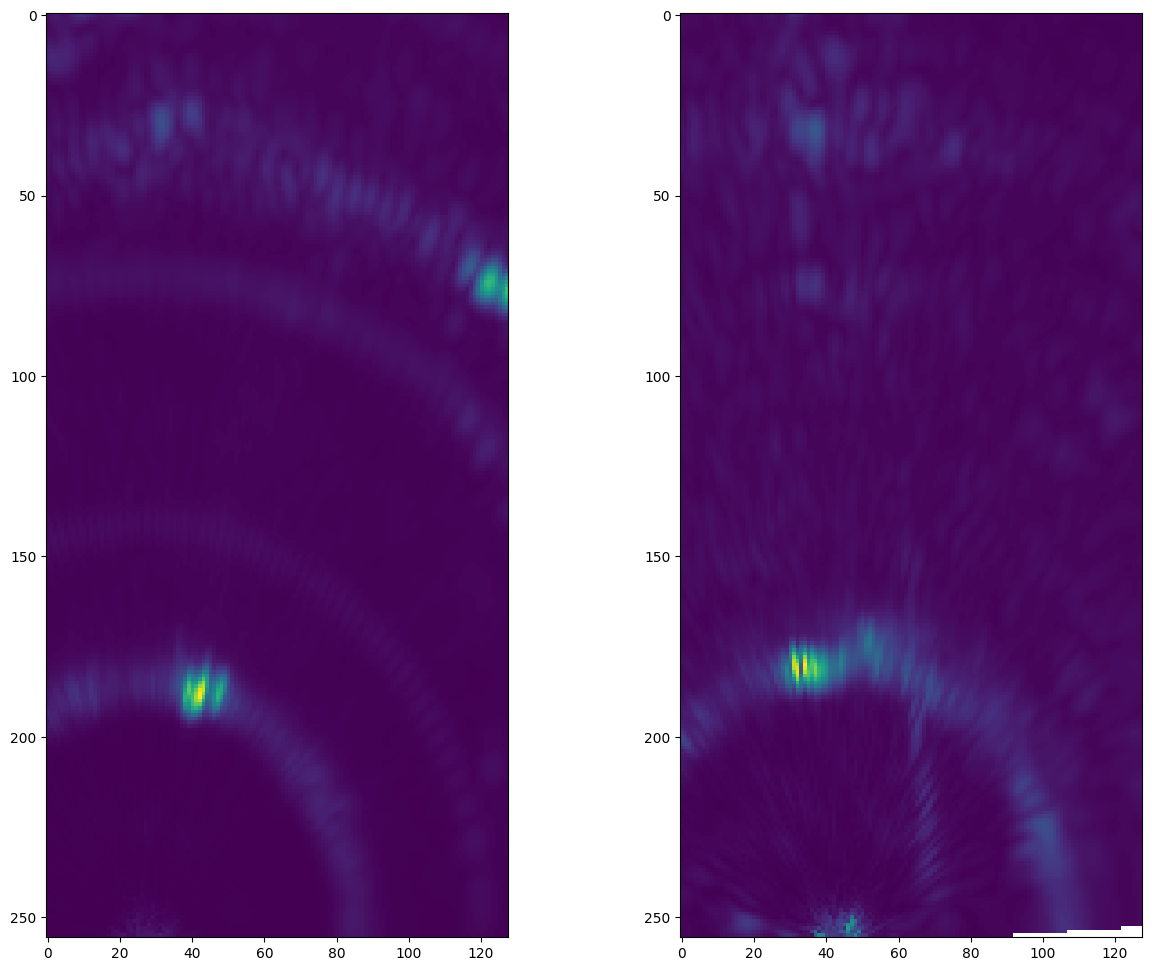

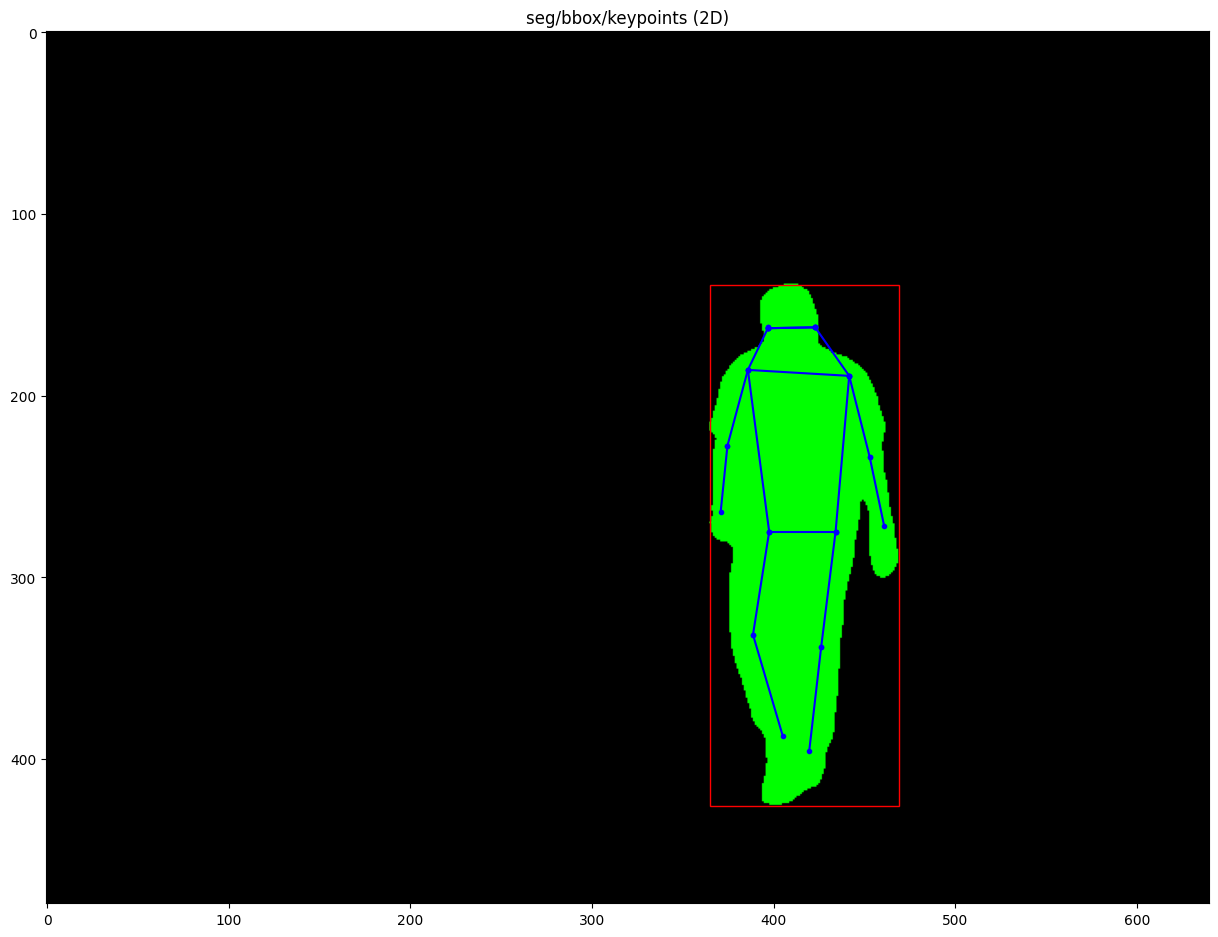

In [9]:
fig = plt.figure(figsize=(15, 12))
ax= fig.add_subplot(1,2,1)
ax.imshow(hori)
ax= fig.add_subplot(1,2,2)
ax.imshow(vert)
plt.show()

fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(1,1,1)
img = np.zeros((480, 640, 3), dtype=np.uint8)

for j in range(mask.shape[0]):
    # seg
    img[mask[j, :,:]] = (0, 255, 0)
    # bbox
    x1, y1, x2, y2 = bbox_i[j,:4]
    width = x2 - x1
    height = y2 - y1
    rect = patches.Rectangle((x1, y1), width, height, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.set_title('seg/bbox/keypoints (2D)')
    # kp
    for connection in connections:
        x = kp[j,connection, 0]
        y = kp[j,connection, 1]
        ax.plot(x, y,color='b',marker='.')
ax.imshow(img)
plt.show()
